# ECSE 415 Course Project: Classification, Detection, and Localization

## README

### Dependencies
```
pip install torch torchvision scikit-learn scikit-image opencv-python tqdm pandas matplotlib pillow torch-lr-finder
```

### Data Setup
1. Download the dataset from the Kaggle competition page, and download the Stanford Dogs Dataset
2. Place the unzipped data in the following structure:

```
part1/
├── train/
│   └── train/
│       ├── cats/
│       └── dogs/
└── test/
    └── test/

part2/
├── Annotation/
└── Images/
```

In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import time
import os
import shutil
import random
import torch
import torchvision.models as models
import pandas as pd
import cv2
from pathlib import Path
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn import metrics
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from pathlib import Path
from PIL import Image
from sklearn.svm import LinearSVC
from skimage.feature import hog

## Part 1: The Classification Benchmark [50 Points]

Path declaration for part 1:

In [4]:
path = './part1/'

In [5]:
path = './part1/'
# Create split folders if they don't exist
os.makedirs(path + 'train/train_split/cats', exist_ok=True)
os.makedirs(path + 'train/train_split/dogs', exist_ok=True)
os.makedirs(path + 'train/test_split/cats', exist_ok=True)
os.makedirs(path + 'train/test_split/dogs', exist_ok=True)

if len(os.listdir(path + 'train/train_split/cats')) == 0:
    cats = Path(path+'/train/train/cats')
    cat_imgs = list(cats.iterdir())
    dogs = Path(path+'/train/train/dogs')
    dog_imgs = list(dogs.iterdir())

    #shuffle all cat and dog images
    random.shuffle(cat_imgs)
    random.shuffle(dog_imgs)

    #split- first 80% -> training, last 20* of list -> internal testing
    split_cats = int(len(cat_imgs) * 0.8)
    split_dogs = int(len(dog_imgs) * 0.8)
    train_cats = cat_imgs[:split_cats]
    test_cats = cat_imgs[split_cats:]
    train_dogs = dog_imgs[:split_dogs]
    test_dogs = dog_imgs[split_dogs:]

    #use shutil to copy images in each list
    for img in train_cats:
        shutil.copy2(img, path+'train/train_split/cats')
    for img in test_cats:
        shutil.copy2(img, path+'train/test_split/cats')
    for img in train_dogs:
        shutil.copy2(img, path+'train/train_split/dogs')
    for img in test_dogs:
        shutil.copy2(img, path+'train/test_split/dogs')

else:
    print("Split already done, skipping.")


Split already done, skipping.


In [6]:
# Verify split counts
train_cats_count = len(os.listdir(path + 'train/train_split/cats'))
train_dogs_count = len(os.listdir(path + 'train/train_split/dogs'))
test_cats_count = len(os.listdir(path + 'train/test_split/cats'))
test_dogs_count = len(os.listdir(path + 'train/test_split/dogs'))

print(f'Train cats: {train_cats_count}')
print(f'Train dogs: {train_dogs_count}')
print(f'Total train: {train_cats_count + train_dogs_count}')
print(f'Test cats: {test_cats_count}')
print(f'Test dogs: {test_dogs_count}')
print(f'Total test: {test_cats_count + test_dogs_count}')

Train cats: 8016
Train dogs: 7983
Total train: 15999
Test cats: 2005
Test dogs: 1996
Total test: 4001


### 1. Method Selection (Training)

**Option A**:

In [ ]:
# Step 1: Defining split directory paths for Option A
optionA_train_catsPath = Path(path + 'train/train_split/cats')
optionA_train_dogsPath = Path(path + 'train/train_split/dogs')
optionA_test_catsPath = Path(path + 'train/test_split/cats')
optionA_test_dogsPath = Path(path + 'train/test_split/dogs')

# Step 2: Setting feature parameters
imgSize = 64
labelNames = ['cat', 'dog']

# This section keeps the aspect ratio, then pads to a square before computing the HOG
# This makes the feature length consistent across all images before classification
def preprocessImage(imagePath, imgSize=64):
    image = cv2.imread(str(imagePath))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    h, w = image.shape
    scale = imgSize / max(h, w)

    newW = int(w * scale)
    newH = int(h * scale)

    resized = cv2.resize(image, (newW, newH))
    padded = np.zeros((imgSize, imgSize), dtype=np.uint8)

    yOffset = (imgSize - newH) // 2
    xOffset = (imgSize - newW) // 2
    padded[yOffset:yOffset + newH, xOffset:xOffset + newW] = resized

    return padded

# The HOG descriptor was implemented following the scikit-image documentation:
# https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.hog
# I use HOG here because it converts each grayscale image into a gradient-based feature vector
def extractHogFeatures(image):
    return hog(image, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')

# Here I am building the feature matrix by extracting one HOG vector per image and storing its class label
def buildFeatureMatrix(catDir, dogDir, imgSize=64):
    featureList = []
    labelList = []

    for imagePath in sorted(catDir.iterdir()):
        featureList.append(extractHogFeatures(preprocessImage(imagePath, imgSize)))
        labelList.append(0)

    for imagePath in sorted(dogDir.iterdir()):
        featureList.append(extractHogFeatures(preprocessImage(imagePath, imgSize)))
        labelList.append(1)

    return np.array(featureList), np.array(labelList)

In [9]:
# Step 3: Building the HOG feature matrices for the training and internal test splits
xTrain, yTrain = buildFeatureMatrix(optionA_train_catsPath, optionA_train_dogsPath, imgSize)
xTest, yTest = buildFeatureMatrix(optionA_test_catsPath, optionA_test_dogsPath, imgSize)

print("Option A training feature matrix shape:", xTrain.shape)
print("Option A testing feature matrix shape:", xTest.shape)

Option A training feature matrix shape: (15999, 1764)
Option A testing feature matrix shape: (4001, 1764)


In [ ]:
# Step 4: Training the classifier
# I referenced the following LinearSVC documentation:
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
# The implemented HOG extracts edge and shape information and the SVM classifies these features by learning a decision boundary between cats and dogs.
classifier = LinearSVC(random_state=42, max_iter=10000)
classifier.fit(xTrain, yTrain)

# Step 5: Evaluating on the internal test split
predictions = classifier.predict(xTest)
accuracy = accuracy_score(yTest, predictions)

print(f'Option A Test Accuracy: {100 * accuracy:.2f}%')

Option A Test Accuracy: 71.38%


**Option B**: PCA + SVM

In [ ]:
# Step 1: Define split directory paths
train_cats_dir = Path(path + 'train/train_split/cats')
train_dogs_dir = Path(path + 'train/train_split/dogs')
test_cats_dir = Path(path + 'train/test_split/cats')
test_dogs_dir = Path(path + 'train/test_split/dogs')
print(len(list(train_cats_dir.iterdir())))
print(len(list(train_dogs_dir.iterdir())))
print(len(list(test_cats_dir.iterdir())))
print(len(list(test_dogs_dir.iterdir())))

# Step 2: Load and preprocess images
# Convert to grayscale, resize to 64x64, flatten into 1D vector
img_size = 64

X_train = []
y_train = []
X_test = []
y_test = []

# Helper function to load images
def load_images(folder, label, image_array, label_array):
    for file_name in os.listdir(folder):
        file_path = folder / file_name
        image = cv2.imread(str(file_path), cv2.IMREAD_GRAYSCALE)

        if image is None:
            continue

        image = cv2.resize(image, (img_size, img_size))
        image = image.flatten()

        image_array.append(image)
        label_array.append(label)

# Load training and testing data
load_images(train_cats_dir, 0, X_train, y_train)
load_images(train_dogs_dir, 1, X_train, y_train)
load_images(test_cats_dir, 0, X_test, y_test)
load_images(test_dogs_dir, 1, X_test, y_test)

# Convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


8016
7983
2005
1996
Training samples: 15999
Testing samples: 4001


In [ ]:
# Step 3: Apply PCA (reduce dimensionality)
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original number of features:", X_train.shape[1])
print("Reduced number of PCA features:", X_train_pca.shape[1])

Original number of features: 4096
Reduced number of PCA features: 907


In [ ]:
# Step 4: Train SVM classifier
classifier = SVC(kernel='rbf', C=10, gamma='scale')
classifier.fit(X_train_pca, y_train)


# Step 5: Evaluate model on test set
predictions = classifier.predict(X_test_pca)

accuracy = accuracy_score(y_test, predictions)
print(f'Test Accuracy: {100 * accuracy:.2f}%')

Test Accuracy: 65.51%


**Option C**: Fine-Tuned ResNet

In [ ]:
# Step 1: Load pre-trained ResNet-18 and modify the final layer for binary classification
# ResNet-18 is chosen over deeper variants (ResNet-34, ResNet-50) to reduce computational
# cost. Performance gains from deeper architectures are marginal for this binary task. (https://arxiv.org/pdf/1512.03385 )
model = models.resnet50(pretrained=True)
num_classes = 2  # cats and dogs

# Replace the final fully connected layer to output 2 classes instead of ImageNet's 1000.
# in_features is preserved from the original layer.
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

/Users/rachel/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/rachel/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Step 2: Preprocess training and testing data
# Apply data augmentation to training data to improve generalization and reduce overfitting.
# Test data is only transformed through normalization.
# Reference for normalization values: https://pytorch.org/hub/pytorch_vision_resnet/
data_transforms = {
    # Apply data augmentation and normalization to training data
    'train': transforms.Compose([
        # Randomly crop and resize to 224x224 to vary scale and position across epochs
        transforms.RandomResizedCrop(224),
        # Randomly apply horizontal flip- this does not affect the fact that image still looks like a cat, and helps with augmentation
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        # Normalize using ImageNet mean and std required for pretrained ResNet weights
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    # Apply just resize+crop and normalization for test set
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

train_dataset = ImageFolder(path+'train/train_split', transform=data_transforms['train'])
test_dataset = ImageFolder(path+'train/test_split', transform=data_transforms['test'])

# Shuffle training data so model sees images in different order at every epoch
# num_workers allows use of 4 cores
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

In [ ]:
# Step 3: Loss function and optimizer
# Momentum value for optimizer chosen following tutorial: https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [ ]:
# Step 4: Model training

def train_model(model, train_loader, loss_function, optimizer, num_epochs):
    # Detect whether we can use GPU, or else use CPU
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Move model's weights/parameters to GPU memory, if available
    model = model.to(device)

    since = time.time()
    for epoch in range(num_epochs):
        # Set model to training mode
        model.train()

        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        total_loss = 0.0
        correct = 0

        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            # Move inputs and labels to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Reset the gradients to zero
            optimizer.zero_grad()
            # Forward pass
            predictions = model(inputs)
            _, predicted_classes = torch.max(predictions, dim=1)
            # Calculate loss
            loss = loss_function(predictions, labels)
            total_loss += loss.item() * inputs.size(0)
            # Backpropagation
            loss.backward()
            # Update weights
            optimizer.step()
            # Get cumulative correct predictions
            correct += torch.sum(predicted_classes == labels.data)

        # Calculate avg training loss and accuracy for epoch
        training_loss = total_loss/len(train_loader.dataset)
        training_accuracy = correct.float() / len(train_loader.dataset)
        print(f'Train loss: {training_loss:.4f}, train acc: {training_accuracy:.4f}')
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

    return model

# Train the model
model = train_model(model, train_loader, loss_function, optimizer, num_epochs=10)

# Save the trained model weights
torch.save(model.state_dict(), 'resnet50.pth')

Using device: mps
Epoch 1/10
--------------------


Epoch 1/10: 100%|██████████| 625/625 [05:33<00:00,  1.87it/s]


Train loss: 0.1247, train acc: 0.9498
Epoch 2/10
--------------------


Epoch 2/10: 100%|██████████| 625/625 [05:41<00:00,  1.83it/s]


Train loss: 0.0814, train acc: 0.9663
Epoch 3/10
--------------------


...

Train loss: 0.0510, train acc: 0.9796
Epoch 9/10
--------------------


Epoch 9/10: 100%|██████████| 625/625 [05:33<00:00,  1.88it/s]


Train loss: 0.0463, train acc: 0.9818
Epoch 10/10
--------------------


Epoch 10/10: 100%|██████████| 625/625 [05:42<00:00,  1.82it/s]


Train loss: 0.0497, train acc: 0.9792
Training complete in 56m 38s


In [ ]:
# Evaluate model on test set
model.eval()

correct = 0
total = 0
# Used for confusion matrix
ResNet_preds = []
true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        # Collect predictions and true labels
        ResNet_preds.extend(predicted.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print(f'Test Accuracy: {100 * correct / total:.2f}%')

Test Accuracy: 99.88%


In [ ]:
# Load saved model
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load('resnet50.pth'))
model.eval()
model = model.to(device)

/Users/rachel/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/rachel/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
kaggle_test_images = Path(path + 'test/test/').iterdir()
ids = []
predictions = []

for img_path in kaggle_test_images:
    image = Image.open(img_path)
    image = data_transforms['test'](image)
    image = image.unsqueeze(0)
    image = image.to(device)
    id = img_path.stem
    with torch.no_grad():
        output = model(image)
        _, prediction = torch.max(output, 1)
    ids.append(id)
    predictions.append(prediction.item())

df = pd.DataFrame({'id': ids, 'label': predictions})
df.to_csv('submission.csv', index=False)

### 2. Local Analysis and Evaluation

A. HOG + Linear SVM Confusion matrix

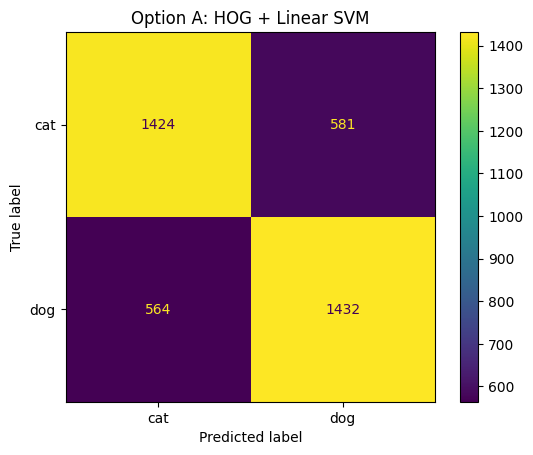

In [11]:
cm = confusion_matrix(yTest, predictions)
cmDisplay = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labelNames)
cmDisplay.plot()
plt.title('Option A: HOG + Linear SVM')
plt.show()

B. PCA + SVM Confusion matrix

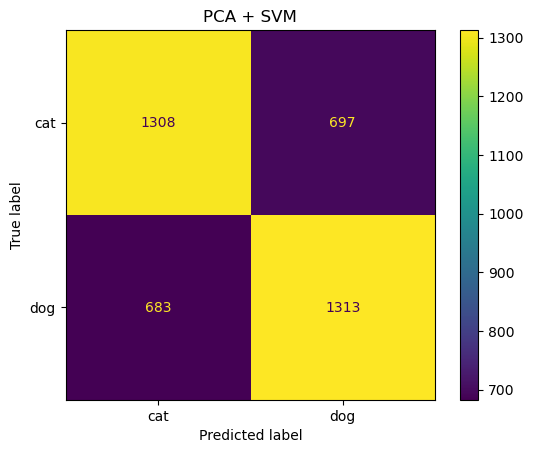

In [ ]:
cm = confusion_matrix(y_test, predictions)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["cat", "dog"])
cm_display.plot()
plt.title('PCA + SVM')
plt.show()

C. ResNet-50 Confusion matrix

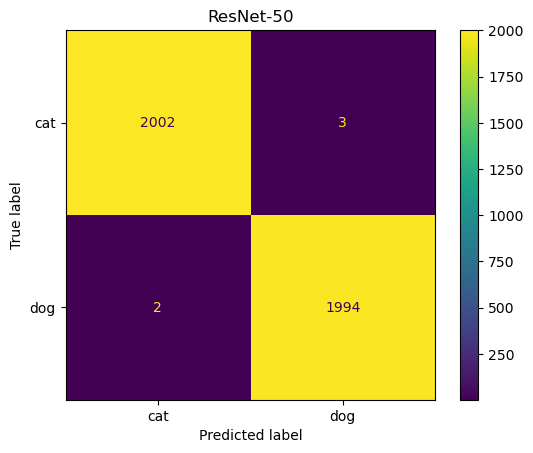

In [ ]:
confusion_matrix = metrics.confusion_matrix(true_labels, ResNet_preds)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ["cat", "dog"])
cm_display.plot()
plt.title('ResNet-50')
plt.show()

## Part 2: Detection and Localization [50 Points]

In [3]:
path = './part2/'

### 4.1 Localization Strategy

In [4]:
import glob
import xml.etree.ElementTree as ET
import matplotlib.patches as patches
from torchvision.ops import nms
from collections import defaultdict

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')

DATA_ROOT  = './part2'
IMG_DIR    = os.path.join(DATA_ROOT, 'Images')
ANN_DIR    = os.path.join(DATA_ROOT, 'Annotation')
CHECKPOINT = 'resnet50.pth'

In [5]:
def load_classifier():
    # Load the best model from Part 1 (ResNet-50 fine-tuned on cats/dogs)
    model = models.resnet50(pretrained=False)
    model.fc = torch.nn.Linear(model.fc.in_features, 2)
    # weights_only=True avoids the security warning from arbitrary pickle loading
    state = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state)
    model.to(DEVICE)
    model.eval()
    return model

def parse_annotation(ann_path):
    # Reference: https://docs.python.org/3/library/xml.etree.elementtree.html
    # Parse a Stanford Dogs XML annotation and return list of (xmin, ymin, xmax, ymax)
    tree = ET.parse(ann_path)
    root = tree.getroot()
    boxes = []
    for obj in root.findall('object'):
        bb = obj.find('bndbox')
        box = (
            int(bb.find('xmin').text),
            int(bb.find('ymin').text),
            int(bb.find('xmax').text),
            int(bb.find('ymax').text),
        )
        boxes.append(box)
    return boxes

def collect_samples(img_dir, ann_dir, max_per_breed=5):
    # Get paired (image_path, annotation_path, breed) tuples
    # max_per_breed limits samples per breed for manageable runtime
    samples = []
    breeds = sorted(os.listdir(img_dir))
    for breed in breeds:
        breed_img_dir = os.path.join(img_dir, breed)
        breed_ann_dir = os.path.join(ann_dir, breed)
        img_files = sorted(glob.glob(os.path.join(breed_img_dir, '*.jpg')))
        breed_samples = []
        for img_path in img_files:
            img_name = os.path.splitext(os.path.basename(img_path))[0]
            ann_path = os.path.join(breed_ann_dir, img_name)
            if os.path.exists(ann_path):
                breed_samples.append((img_path, ann_path, breed))
        random.shuffle(breed_samples)
        samples.extend(breed_samples[:max_per_breed])
    return samples

In [9]:
def selective_search(img_bgr, max_proposals=500):
    # Reference: https://learnopencv.com/selective-search-for-object-detection-cpp-python/
    # Use OpenCV selective search to generate region proposals
    # switchToSelectiveSearchFast is used for speed; Quality mode is ~10x slower
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(img_bgr)
    ss.switchToSelectiveSearchFast()
    rects = ss.process()
    return rects[:max_proposals]

def score_proposals(img_rgb, proposals, model, batch_size=64, dog_class_idx=1):
    # Score each region proposal with the classifier.
    # Returns one score per proposal (invalid crops get score 0.0).
    scores = np.zeros(len(proposals), dtype=np.float32)
    h, w = img_rgb.shape[:2]

    # ImageNet normalisation constants — must match the fine-tuning preprocessing
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 1, 3)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 1, 3)

    for start in range(0, len(proposals), batch_size):
        batch_props = proposals[start:start + batch_size]
        batch_tensors = []
        valid_local_indices = []  # track which proposals produced valid crops

        for local_i, (x, y, pw, ph) in enumerate(batch_props):
            x1, y1 = max(0, int(x)), max(0, int(y))
            x2, y2 = min(w, int(x + pw)), min(h, int(y + ph))

            if x2 <= x1 or y2 <= y1:
                continue  # invalid crop — leave score as 0.0

            crop = img_rgb[y1:y2, x1:x2].astype(np.float32) / 255.0
            crop = cv2.resize(crop, (224, 224))
            crop = (crop - mean) / std
            tensor = torch.from_numpy(crop).permute(2, 0, 1).float()
            batch_tensors.append(tensor)
            valid_local_indices.append(local_i)

        if not batch_tensors:
            continue  # entire mini-batch had no valid crops

        batch = torch.stack(batch_tensors).to(DEVICE)
        with torch.no_grad():
            logits = model(batch)
            probs = torch.softmax(logits, dim=1)

        for j, local_i in enumerate(valid_local_indices):
            scores[start + local_i] = probs[j, dog_class_idx].item()

    return scores

def apply_nms(proposals, scores, score_thresh=0.5, iou_thresh=0.3):
    # Reference: https://github.com/FrancescoSaverioZuppichini/non-max-suppression-in-pytorch
    # Convert (x, y, w, h) -> (xmin, ymin, xmax, ymax)
    boxes_xyxy = np.stack([
        proposals[:, 0],
        proposals[:, 1],
        proposals[:, 0] + proposals[:, 2],
        proposals[:, 1] + proposals[:, 3],
    ], axis=1).astype(np.float32)

    mask = scores >= score_thresh
    if mask.sum() == 0:
        # Fall back to the single highest-scoring proposal when nothing clears the threshold
        best = int(scores.argmax())
        return boxes_xyxy[best:best+1], scores[best:best+1]

    filtered_boxes  = torch.tensor(boxes_xyxy[mask])
    filtered_scores = torch.tensor(scores[mask])
    keep = nms(filtered_boxes, filtered_scores, iou_threshold=iou_thresh)
    return filtered_boxes[keep].numpy(), filtered_scores[keep].numpy()

def detect_dog(img_path, model, score_thresh=0.5, iou_thresh=0.3, max_proposals=500):
    # Full pipeline: selective search -> score proposals -> NMS -> best box
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    proposals   = selective_search(img_bgr, max_proposals=max_proposals)
    scores      = score_proposals(img_rgb, proposals, model)
    kept_boxes, kept_scores = apply_nms(proposals, scores, score_thresh=score_thresh, iou_thresh=iou_thresh)
    best_idx    = int(kept_scores.argmax())
    best_box    = kept_boxes[best_idx].astype(int)
    best_score  = float(kept_scores[best_idx])
    return best_box, best_score, img_rgb, kept_boxes, kept_scores

In [10]:
def visualize_prediction(img_rgb, best_box, best_score, gt, kept_boxes=None, kept_scores=None):
    _, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img_rgb)

    # Draw all kept proposals above score 0.5 in blue
    if kept_boxes is not None and kept_scores is not None:
        for (x1, y1, x2, y2), score in zip(kept_boxes, kept_scores):
            if score >= 0.5:
                prop_rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                              linewidth=1, edgecolor='blue',
                                              facecolor='none', alpha=0.5)
                ax.add_patch(prop_rect)
                ax.text(x1, y1 - 5, f'{score:.2f}', color='blue', fontsize=8)

    # Draw ground-truth box(es) in green
    for (x1, y1, x2, y2) in gt:
        gt_rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     linewidth=2, edgecolor='green', facecolor='none')
        ax.add_patch(gt_rect)

    # Draw best predicted box in red
    x1, y1, x2, y2 = best_box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                               linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, f'Best: {best_score:.2f}', color='red', fontsize=10)

    plt.axis('off')
    plt.show()

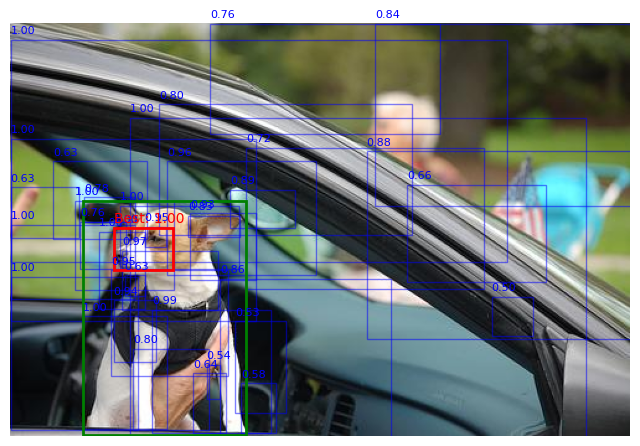

In [11]:
# Load classifier and dataset, then visualize one sample detection
classifier = load_classifier()
samples = collect_samples(IMG_DIR, ANN_DIR, max_per_breed=5)

img_path, ann_path, _ = samples[0]
gt = parse_annotation(ann_path)
best_box, best_score, img_rgb, kept_boxes, kept_scores = detect_dog(img_path, classifier)
visualize_prediction(img_rgb, best_box, best_score, gt, kept_boxes, kept_scores)

### 4.2 Analysis and Evaluation

This section evaluates the detection pipeline on the Stanford Dogs dataset using Intersection over Union (IoU) as the primary metric.

- **Quantitative Evaluation**: IoU is computed per image by comparing the predicted bounding box with the ground truth annotation.
- **Successes & Failures**: Visual examples are selected from the highest and lowest IoU results.
- **Qualitative Discussion**: Failure cases are analyzed for root causes (e.g., occlusion, clutter, scale).
- **(Bonus) Breed Analysis**: Per-breed IoU statistics reveal which dog breeds the pipeline handles well vs. poorly.

In [12]:
def compute_iou(pred_box, gt_box):
    """
    Compute IoU between a single predicted box and a single ground-truth box.
    Both boxes are in (xmin, ymin, xmax, ymax) format.
    Reference: https://pyimagesearch.com/2016/11/07/intersection-over-union-iou-for-object-detection/
    """
    px1, py1, px2, py2 = pred_box
    gx1, gy1, gx2, gy2 = gt_box

    # Intersection rectangle
    ix1 = max(px1, gx1)
    iy1 = max(py1, gy1)
    ix2 = min(px2, gx2)
    iy2 = min(py2, gy2)

    inter_w = max(0, ix2 - ix1)
    inter_h = max(0, iy2 - iy1)
    intersection = inter_w * inter_h

    pred_area = max(0, px2 - px1) * max(0, py2 - py1)
    gt_area   = max(0, gx2 - gx1) * max(0, gy2 - gy1)
    union = pred_area + gt_area - intersection

    if union == 0:
        return 0.0
    return intersection / union

def best_iou(pred_box, gt_boxes):
    """Return the highest IoU between the predicted box and any ground-truth box."""
    return max(compute_iou(pred_box, gt) for gt in gt_boxes)

In [13]:
# ── Batch Evaluation ──────────────────────────────────────────────────────────
# Limit to 2 samples per breed (~120 images total) for manageable runtime.
# Selective Search fast mode + 500 proposals keeps each image under ~2 s.

# Pick up to 2 images per breed from the pre-collected sample list
from collections import defaultdict as _dd
_breed_counts = _dd(int)
eval_samples = []
for s in samples:
    if _breed_counts[s[2]] < 2:
        eval_samples.append(s)
        _breed_counts[s[2]] += 1
print(f'Running batch evaluation on {len(eval_samples)} images ({len(_breed_counts)} breeds, up to 2/breed)...')

results = []  # list of dicts, one per image

for img_path, ann_path, breed in tqdm(eval_samples, desc='Evaluating'):
    gt_boxes = parse_annotation(ann_path)
    try:
        best_box, best_score, img_rgb, kept_boxes, kept_scores = detect_dog(
            img_path, classifier
        )
        iou = best_iou(best_box.tolist(), gt_boxes)
    except Exception as e:
        # If detection fails for any reason, record IoU = 0
        print(f'  [WARN] {img_path}: {e}')
        iou        = 0.0
        best_box   = np.zeros(4, dtype=int)
        best_score = 0.0
        img_rgb    = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        kept_boxes, kept_scores = np.zeros((0, 4)), np.zeros(0)

    results.append({
        'img_path':    img_path,
        'breed':       breed,
        'iou':         iou,
        'best_box':    best_box,
        'best_score':  best_score,
        'gt_boxes':    gt_boxes,
        'img_rgb':     img_rgb,
        'kept_boxes':  kept_boxes,
        'kept_scores': kept_scores,
    })

print(f'\nEvaluated {len(results)} images.')

Running batch evaluation on 240 images (120 breeds, up to 2/breed)...


Evaluating: 100%|██████████| 240/240 [19:03<00:00,  4.76s/it]


Evaluated 240 images.


  Number of images evaluated : 240
  Mean IoU                   : 0.3870
  Median IoU                 : 0.3336
  Std IoU                    : 0.2478
  Min IoU                    : 0.0000
  Max IoU                    : 0.9786
  IoU >= 0.5  (TP rate)      : 28.3%
  IoU >= 0.25                : 62.1%


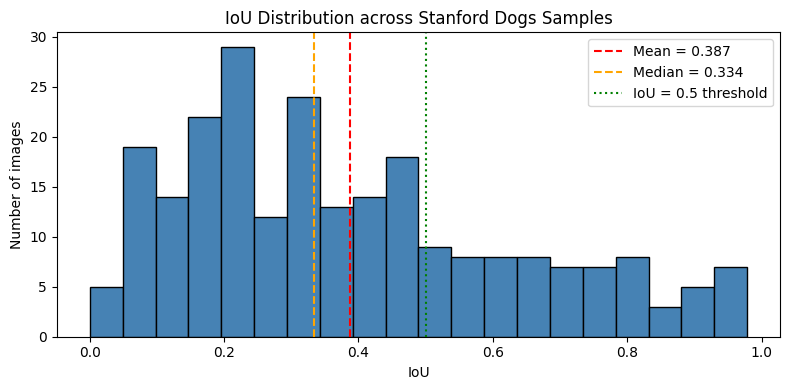

In [14]:
# ── 4.2.1  Quantitative Evaluation — IoU Statistics ──────────────────────────

ious = np.array([r['iou'] for r in results])

print('=' * 45)
print(f'  Number of images evaluated : {len(ious)}')
print(f'  Mean IoU                   : {ious.mean():.4f}')
print(f'  Median IoU                 : {np.median(ious):.4f}')
print(f'  Std IoU                    : {ious.std():.4f}')
print(f'  Min IoU                    : {ious.min():.4f}')
print(f'  Max IoU                    : {ious.max():.4f}')
print(f'  IoU >= 0.5  (TP rate)      : {(ious >= 0.5).mean()*100:.1f}%')
print(f'  IoU >= 0.25                : {(ious >= 0.25).mean()*100:.1f}%')
print('=' * 45)

# IoU distribution histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ious, bins=20, edgecolor='black', color='steelblue')
ax.axvline(ious.mean(),      color='red',    linestyle='--', linewidth=1.5, label=f'Mean = {ious.mean():.3f}')
ax.axvline(np.median(ious),  color='orange', linestyle='--', linewidth=1.5, label=f'Median = {np.median(ious):.3f}')
ax.axvline(0.5,              color='green',  linestyle=':',  linewidth=1.5, label='IoU = 0.5 threshold')
ax.set_xlabel('IoU')
ax.set_ylabel('Number of images')
ax.set_title('IoU Distribution across Stanford Dogs Samples')
ax.legend()
plt.tight_layout()
plt.show()

Legend:  Green = Ground Truth   |   Blue = Predicted (IoU >= 0.5)   |   Red = Predicted (IoU < 0.5)



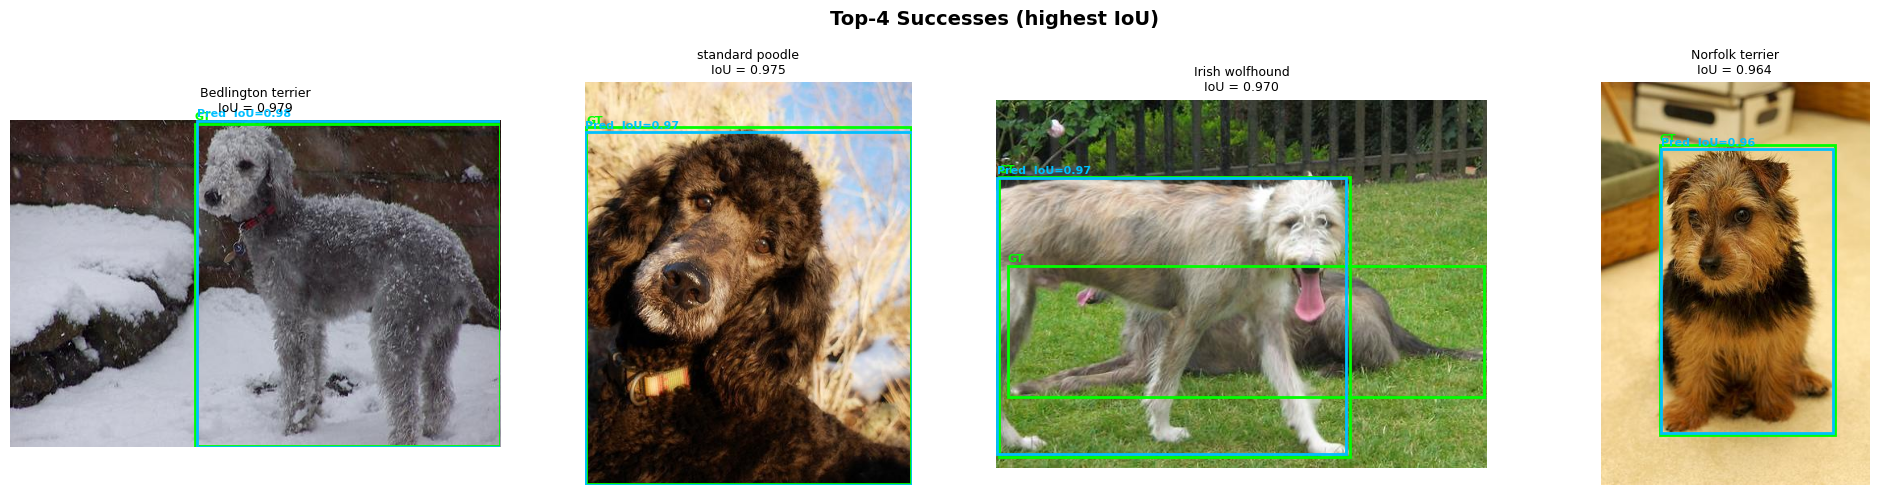

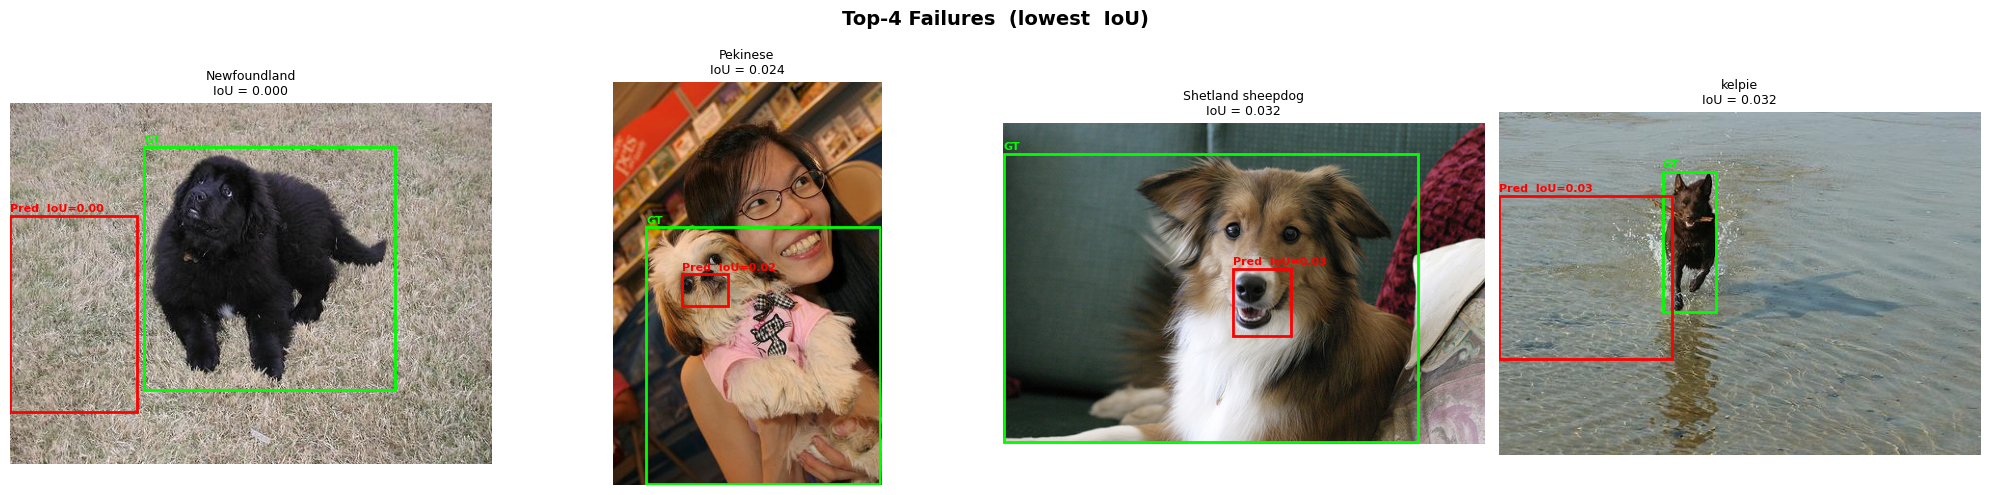

In [15]:
# ── 4.2.2  Successes & Failures ───────────────────────────────────────────────
# Show the top-N highest-IoU (successes) and lowest-IoU (failures) side by side.

N_SHOW = 4

sorted_results = sorted(results, key=lambda r: r['iou'])
failures  = sorted_results[:N_SHOW]
successes = sorted_results[-N_SHOW:][::-1]

def plot_grid(samples_list, title, iou_color_thresh=0.5):
    n = len(samples_list)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for ax, r in zip(axes, samples_list):
        ax.imshow(r['img_rgb'])

        # Ground-truth box in green
        for (x1, y1, x2, y2) in r['gt_boxes']:
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                      linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, 'GT', color='lime', fontsize=8, fontweight='bold')

        # Predicted box: blue if IoU >= threshold, red otherwise
        px1, py1, px2, py2 = r['best_box']
        color = 'deepskyblue' if r['iou'] >= iou_color_thresh else 'red'
        pred_rect = patches.Rectangle((px1, py1), px2 - px1, py2 - py1,
                                       linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(pred_rect)
        ax.text(px1, py1 - 4, f"Pred  IoU={r['iou']:.2f}", color=color, fontsize=8, fontweight='bold')

        breed_short = r['breed'].split('-', 1)[-1].replace('_', ' ')
        ax.set_title(f"{breed_short}\nIoU = {r['iou']:.3f}", fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print('Legend:  Green = Ground Truth   |   Blue = Predicted (IoU >= 0.5)   |   Red = Predicted (IoU < 0.5)\n')
plot_grid(successes, f'Top-{N_SHOW} Successes (highest IoU)')
plot_grid(failures,  f'Top-{N_SHOW} Failures  (lowest  IoU)')

### 4.2.3 Qualitative Discussion

**Why does the pipeline succeed?**
- When the dog occupies most of the frame and has a uniform, contrasting background, Selective Search generates tight proposals around the dog, and the ResNet-50 classifier scores the correct region highly.
- Well-groomed breeds with distinctive coat textures (e.g., Miniature Schnauzer, Golden Retriever) tend to produce strong activations because those patterns were frequent in the fine-tuning data.

**Common failure modes and root causes:**

| Failure mode | Root cause |
|---|---|
| **Background clutter** | Selective Search proposes many background regions; the classifier may score grass, furniture, or people nearly as highly as the dog itself. |
| **Small or distant dog** | Proposals at natural scale are much larger than the actual dog. After resizing to 224×224 the dog occupies only a tiny fraction of the crop, diluting its signal. |
| **Occlusion / partial view** | If the dog is partially hidden by objects or image boundaries, the classifier sees an incomplete appearance that differs from full-body training examples. |
| **Unusual pose** | A dog lying on its back or jumping mid-air changes the aspect ratio and silhouette drastically, confusing both Selective Search and the classifier. |
| **Multiple dogs** | The pipeline returns a single best box; if multiple dogs are present the remaining dogs are missed. |
| **Lighting / low contrast** | Poor lighting or washed-out images reduce the discriminative texture features the CNN relies on. |
| **Breed blends into background** | Light-coloured dogs on sand, or dark dogs in shade, make it harder for Selective Search to segment them as distinct regions. |

**General observation:** Selective Search is region-agnostic; it segments by colour and texture similarity, not semantic meaning. Errors at the proposal stage cannot be recovered by the classifier alone.

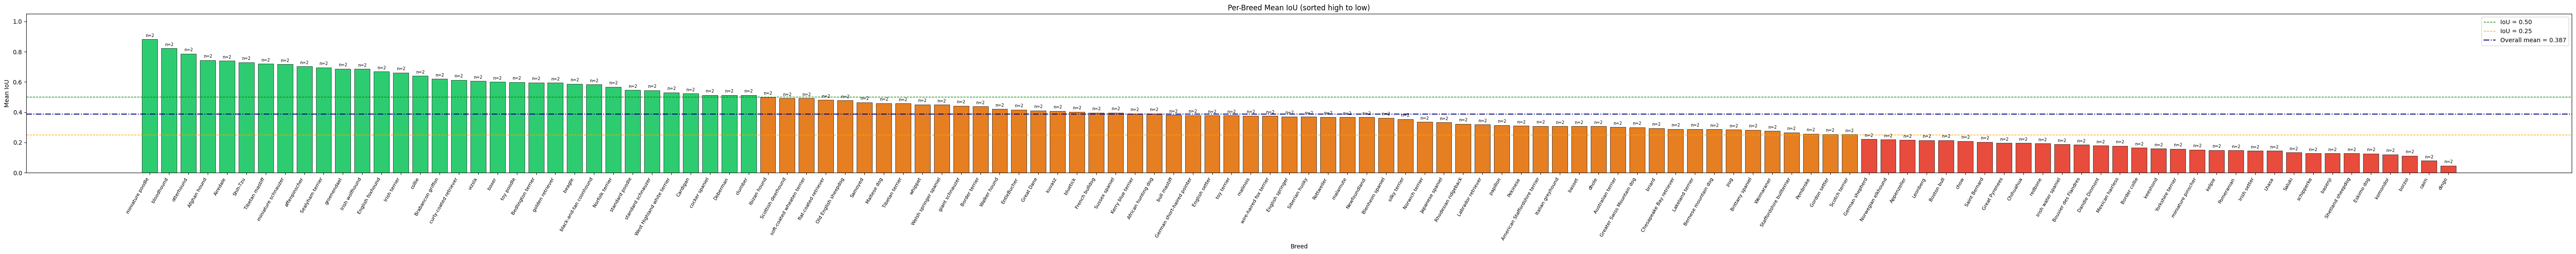


Top-5 breeds (best IoU):
  miniature poodle                     mean IoU = 0.882  (n=2)
  bloodhound                           mean IoU = 0.822  (n=2)
  otterhound                           mean IoU = 0.787  (n=2)
  Afghan hound                         mean IoU = 0.745  (n=2)
  Airedale                             mean IoU = 0.740  (n=2)

Bottom-5 breeds (worst IoU):
  Eskimo dog                           mean IoU = 0.126  (n=2)
  komondor                             mean IoU = 0.121  (n=2)
  borzoi                               mean IoU = 0.112  (n=2)
  cairn                                mean IoU = 0.080  (n=2)
  dingo                                mean IoU = 0.046  (n=2)


In [16]:
# ── (BONUS) 4.2.4  Per-Breed IoU Analysis ────────────────────────────────────
# Group results by breed and compute mean IoU per breed, then plot a ranked bar chart.

breed_ious = defaultdict(list)
for r in results:
    breed_ious[r['breed']].append(r['iou'])

breed_stats = []
for breed, iou_list in breed_ious.items():
    short = breed.split('-', 1)[-1].replace('_', ' ')
    breed_stats.append((short, np.mean(iou_list), len(iou_list)))

breed_stats.sort(key=lambda x: x[1], reverse=True)

names     = [b[0] for b in breed_stats]
mean_ious = [b[1] for b in breed_stats]
counts    = [b[2] for b in breed_stats]

colors = ['#2ecc71' if v >= 0.5 else '#e67e22' if v >= 0.25 else '#e74c3c' for v in mean_ious]

fig, ax = plt.subplots(figsize=(max(12, len(names) * 0.5), 6))
bars = ax.bar(names, mean_ious, color=colors, edgecolor='black', linewidth=0.5)

for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'n={n}', ha='center', va='bottom', fontsize=7)

ax.axhline(0.5,  color='green',  linestyle='--', linewidth=1,   label='IoU = 0.50')
ax.axhline(0.25, color='orange', linestyle='--', linewidth=1,   label='IoU = 0.25')
ax.axhline(np.mean(mean_ious), color='navy', linestyle='-.', linewidth=1.5,
           label=f'Overall mean = {np.mean(mean_ious):.3f}')

ax.set_xlabel('Breed')
ax.set_ylabel('Mean IoU')
ax.set_title('Per-Breed Mean IoU (sorted high to low)')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=60, ha='right', fontsize=8)
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop-5 breeds (best IoU):')
for name, mean_iou, n in breed_stats[:5]:
    print(f'  {name:<35}  mean IoU = {mean_iou:.3f}  (n={n})')

print('\nBottom-5 breeds (worst IoU):')
for name, mean_iou, n in breed_stats[-5:]:
    print(f'  {name:<35}  mean IoU = {mean_iou:.3f}  (n={n})')